<a href="https://colab.research.google.com/github/Rafhaeloktafandhi/Analisis-runtun-waktu/blob/main/Copy_of_Praktikum_ARW_1_Stasioneritas_dan_ARIMA_mahasiswa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Klik file--> save a copy in drive dulu

# Analisis Runtun Waktu

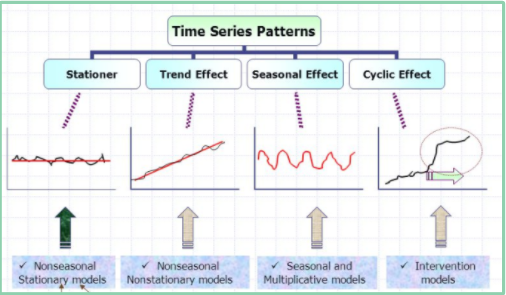


#Persiapan Library

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
plt.rcParams['figure.figsize'] = 12, 6            #agar semua plot ukurannya sama
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from pmdarima.arima import auto_arima
from scipy import stats
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

# Pre-processing pada data time series

Ada beberapa hal yang perlu diperhatikan dalam mengolah data time series:   

*   Interval waktu harus konsisten
*   Kelengkapan data dalam tiap interval waktu



## Mengatasi Missing Data
Missing value kejadian yang lazim terjadi, karena misalnya alat sensor yang tidak selalu berfungsi setiap hari

In [ ]:
#Missing Data
suhu_ciputat = pd.DataFrame(
    {"Tanggal": pd.date_range(start="2025-01-01", periods=10, freq="D"),  #Membuat data tanggal dari 1 jan 2025 hingga 10 hari (data harian)
     "Suhu": [33, 35, np.nan, 33, 34, 32, 30, np.nan, 34, 35]}
)
suhu_ciputat

,Tanggal,Suhu
0,2025-01-01,33.0
1,2025-01-02,35.0
2,2025-01-03,NaN
3,2025-01-04,33.0
4,2025-01-05,34.0
5,2025-01-06,32.0
6,2025-01-07,30.0
7,2025-01-08,NaN
8,2025-01-09,34.0
9,2025-01-10,35.0


Solusi : interpolasi, yaitu rata-rata dari data sebelum dan sesudahnya. Atau bisa juga menggunakan rumus:   

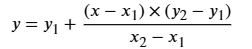

Contoh penggunaan:

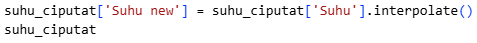

In [ ]:
suhu_ciputat['Suhu new'] = suhu_ciputat['Suhu'].interpolate()
suhu_ciputat

,Tanggal,Suhu,Suhu new
0,2025-01-01,33.0,33.0
1,2025-01-02,35.0,35.0
2,2025-01-03,NaN,34.0
3,2025-01-04,33.0,33.0
4,2025-01-05,34.0,34.0
5,2025-01-06,32.0,32.0
6,2025-01-07,30.0,30.0
7,2025-01-08,NaN,32.0
8,2025-01-09,34.0,34.0
9,2025-01-10,35.0,35.0


## Mendeteksi outlier dan menggantikan data dengan interpolasi
Terkadang sensor error di waktu tertentu sehingga datanya aneh dan kita perlu memperbaiki data outlier

In [ ]:
#Misalkan kita tambahkan outlier di data sebelumnya
suhu_ciputat.loc[6, 'Suhu new']=50
suhu_ciputat

,Tanggal,Suhu,Suhu new
0,2025-01-01,33.0,33.0
1,2025-01-02,35.0,35.0
2,2025-01-03,NaN,34.0
3,2025-01-04,33.0,33.0
4,2025-01-05,34.0,34.0
5,2025-01-06,32.0,32.0
6,2025-01-07,30.0,50.0
7,2025-01-08,NaN,32.0
8,2025-01-09,34.0,34.0
9,2025-01-10,35.0,35.0


Deteksi outlier dengan zscore lalu implementasikan interpolasi

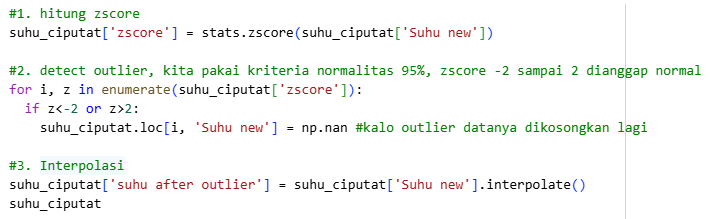

In [ ]:
#1. hitung zscore
suhu_ciputat['zscore'] = stats.zscore(suhu_ciputat['Suhu new'])

#2. detect outlier, kita pakai kriteria normalitas 95%, zscore -2 sampai 2 dianggap normal
for i, z in enumerate(suhu_ciputat['zscore']):
    if z < -2 or z > 2:
        suhu_ciputat.loc[i, 'Suhu new'] = np.nan
    ... #kalo outlier datanya dikosongkan lagi

#3. Interpolasi
suhu_ciputat['suhu after outlier'] = suhu_ciputat['Suhu new'].interpolate()
suhu_ciputat

,Tanggal,Suhu,Suhu new,zscore,suhu after outlier
0,2025-01-01,33.0,33.0,NaN,33.0
1,2025-01-02,35.0,35.0,NaN,35.0
2,2025-01-03,NaN,34.0,NaN,34.0
3,2025-01-04,33.0,33.0,NaN,33.0
4,2025-01-05,34.0,34.0,NaN,34.0
5,2025-01-06,32.0,32.0,NaN,32.0
6,2025-01-07,30.0,NaN,NaN,32.0
7,2025-01-08,NaN,32.0,NaN,32.0
8,2025-01-09,34.0,34.0,NaN,34.0
9,2025-01-10,35.0,35.0,NaN,35.0


## Masalah interval waktu
Selain missing value, terkadang data yang terkumpul juga tidak konsisten. Misalnya ada yang jaraknya 2 hari, ada yang 5 hari, bahkan 10 hari. Untuk itu perlu dilakukan resampling data.

In [ ]:
suhu_bekasi = pd.DataFrame(
    {"Tanggal": ["2025-01-01 10:00", "2025-01-01 11:00", "2025-01-01 14:30", "2025-01-01 15:00", "2025-01-01 15:30", "2025-01-01 16:30", "2025-01-01 17:30", "2025-01-01 19:30"],  #Membuat data per jam
     "Suhu": [33, 35, 35, 34, 34, 32, 30, 28]}
)
suhu_bekasi

,Tanggal,Suhu
0,2025-01-01 10:00,33
1,2025-01-01 11:00,35
2,2025-01-01 14:30,35
3,2025-01-01 15:00,34
4,2025-01-01 15:30,34
5,2025-01-01 16:30,32
6,2025-01-01 17:30,30
7,2025-01-01 19:30,28


Kode resampling :    

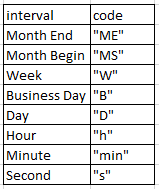

contoh : kalo per 2 jam berarti kodenya jadi "2h", tapi kalo 1 jam cukup "h" saja. Contoh buat per 30 menit:

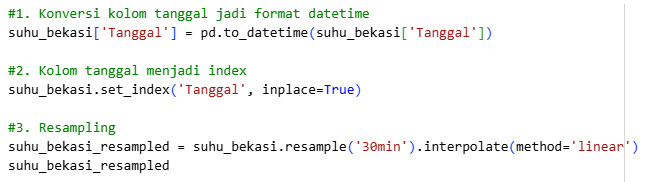

In [ ]:
#1. Konversi kolom tanggal jadi format datetime
suhu_bekasi['Tanggal'] = pd.to_datetime(suhu_bekasi['Tanggal'])

#2. Kolom tanggal menjadi index
suhu_bekasi.set_index('Tanggal', inplace=True)

#3. Resampling
suhu_bekasi_resampled = suhu_bekasi.resample('30min').interpolate(method='linear')
suhu_bekasi_resampled


,Suhu
Tanggal,
2025-01-01 10:00:00,33.0
2025-01-01 10:30:00,34.0
2025-01-01 11:00:00,35.0
2025-01-01 11:30:00,35.0
2025-01-01 12:00:00,35.0
2025-01-01 12:30:00,35.0
2025-01-01 13:00:00,35.0
2025-01-01 13:30:00,35.0
2025-01-01 14:00:00,35.0


# Model Trend

In [ ]:
# Bikin data trend
np.random.seed(42)
n = 60
t = np.arange(n)

beta0 = 100       # intercept
beta1 = 5         # slope (naik 5/bulan)
noise = np.zeros(n)
for i in range(1, n):
    noise[i] = 0.6 * noise[i-1] + np.random.normal(0, 8)

data_trend = beta0 + beta1 * t + noise
data_trend

array([100.        , 108.97371322, 111.27811353, 120.94837642,
       135.7532647 , 132.57873182, 132.67414344, 149.23818859,
       154.68239099, 150.0536395 , 157.37266405, 155.71625689,
       156.7039161 , 164.95804784, 154.66858674, 152.00180939,
       161.7027854 , 165.91902228, 181.06539203, 182.37504261,
       181.12659596, 205.40114773, 208.43447823, 214.60091258,
       208.36256206, 213.66247544, 224.08486598, 222.24297097,
       235.35136673, 237.40571052, 243.10987631, 246.05227289,
       269.44958921, 270.56177573, 264.87537801, 278.5055861 ,
       272.33660246, 282.07287024, 272.56636115, 273.9143283 ,
       288.92348687, 304.26182476, 310.92804111, 314.6316384 ,
       317.37015348, 311.59391616, 316.19759603, 323.03344745,
       341.27704628, 348.51517408, 338.00478321, 350.39554168,
       354.15666676, 356.07862406, 369.54058474, 382.97234703,
       392.23364917, 385.62644932, 387.90217058, 396.3914098 ])

## Visualisasikan data
Pertama-tama kita bisa hitung statistik deskriptif perjangka waktu tertentu dan melihat fluktuasi datanya

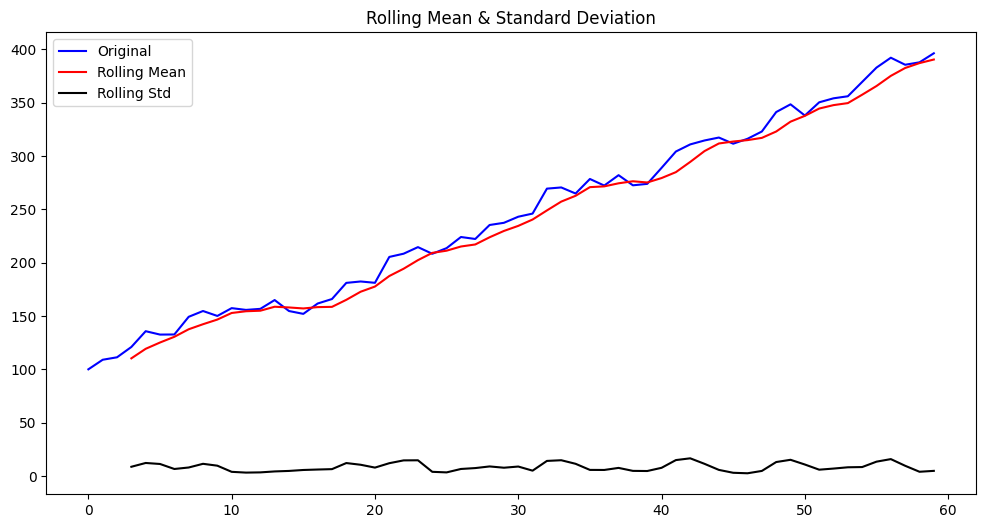

In [ ]:
#Menghitung rolling statistics
data_trend_series = pd.Series(data_trend) # Convert numpy array ke pandas Series
rolmean = data_trend_series.rolling(window=4).mean()
rolstd = data_trend_series.rolling(window=4).std()

#Plot rolling statistics:
orig = plt.plot(data_trend_series, color='blue',label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

Terlihat rolling standar deviasinya relatif stabil, plot data dan rolling meannya konsisten naik, sehingga cocok untuk menggunakan model trend. Dalam time series, model trend sama aja seperti regresi linier dengan variabel independentnya adalah waktu (t). Karena prosesnya sama dengan regresi linier, jadi kita skip saja.

# Model ARIMA

In [ ]:
#Download data
!wget https://raw.githubusercontent.com/jacobstallone/Time_Series_ARIMA--Blog-and-code-/master/AirPassengers.csv

--2026-05-31 10:29:50--  https://raw.githubusercontent.com/jacobstallone/Time_Series_ARIMA--Blog-and-code-/master/AirPassengers.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1746 (1.7K) [text/plain]
Saving to: ‘AirPassengers.csv’

AirPassengers.csv   100%[===================>]   1.71K  --.-KB/s    in 0s      

2026-05-31 10:29:50 (22.2 MB/s) - ‘AirPassengers.csv’ saved [1746/1746]



In [ ]:
#Load data
data_passenger = pd.read_csv('AirPassengers.csv')
data_passenger

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [ ]:
#Mengubah tanggal menjadi index
#con=data_passenger['Month']
data_passenger['Month']=pd.to_datetime(data_passenger['Month'])
data_passenger.set_index('Month', inplace=True)
#check datatype of index
data_passenger.index

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', name='Month', length=144, freq=None)

## Visualisasikan data

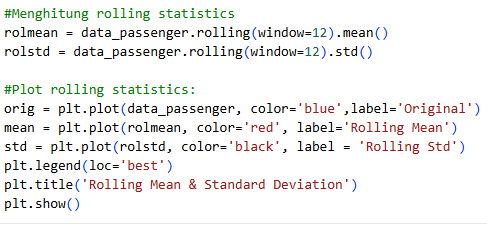

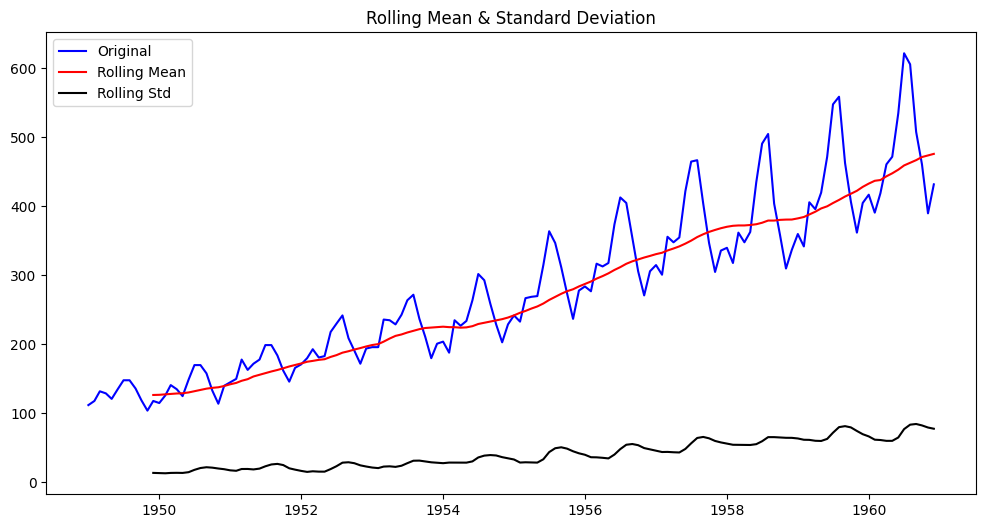

In [ ]:
#Menghitung rolling statistics
rolmean = data_passenger.rolling(window=12).mean()
rolstd = data_passenger.rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(data_passenger, color='blue',label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

Baik standard deviasi dan rata-rata berubah seiring waktu. Sehingga datanya tidak stasioner dan juga tidak mengikuti pola trend.

## Uji diagnostik stasioneritas
Selain dari visualisasi, kita juga bisa uji stasioner dengan uji statistik Dickey-Fuller test

Ho : data tidak stasioner

Ha : data stasioner

In [ ]:
#Perform Dickey-Fuller test:
dftest = adfuller(data_passenger, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


 Menurut uji Dickey-Fuller, p-value = 0.99 > 0.05, sehingga kalo menggunakan CI 95% Ho gagal ditolak, data tidak stasioner. Nah, jika kita tetap ingin menggunakan model ARIMA, kita harus melakukan transformasi atau differencing

## Transformasi atau Differencing
Data bisa ditransformasi log, kuadrat, dll atau differencing beberapa kali hingga data menjadi stasioner.

### 1. Coba Differencing

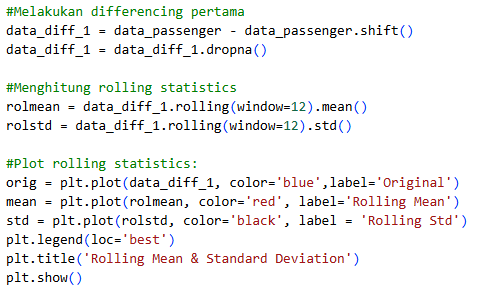

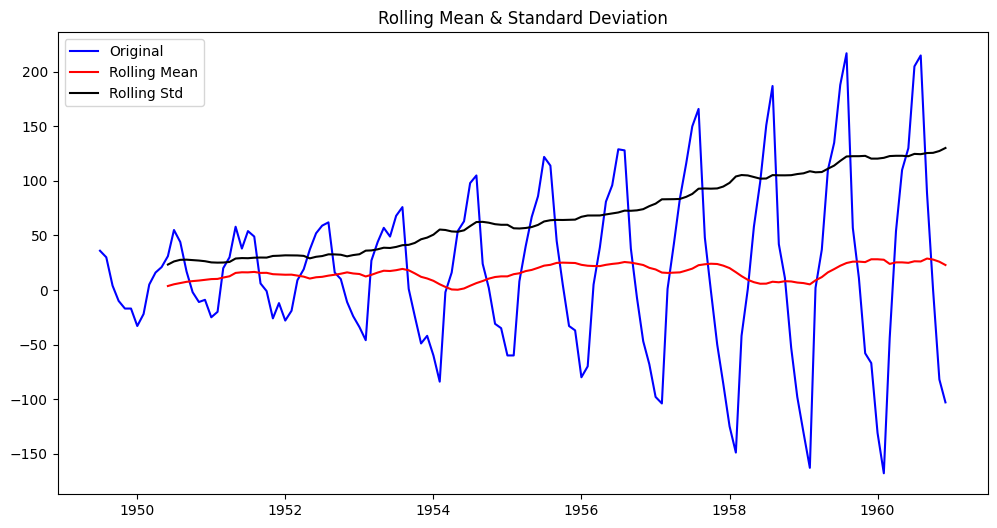

In [ ]:
#Melakukan differencing pertama
data_diff_1 = data_passenger - data_passenger.shift()
data_diff_1 = data_diff_1.dropna()

#Menghitung rolling statistics
rolmean = data_diff_1.rolling(window=12).mean()
rolstd = data_diff_1.rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(data_diff_1, color='blue',label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

Udah stasioner secara rata-rata, tapi belum stasioner secara standard deviasi

### 2. Coba Transformasi log

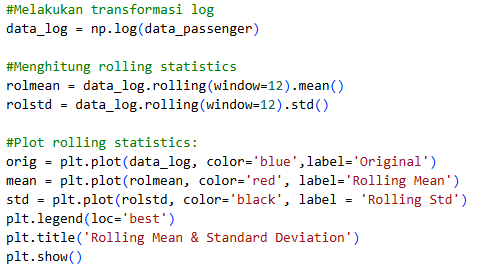

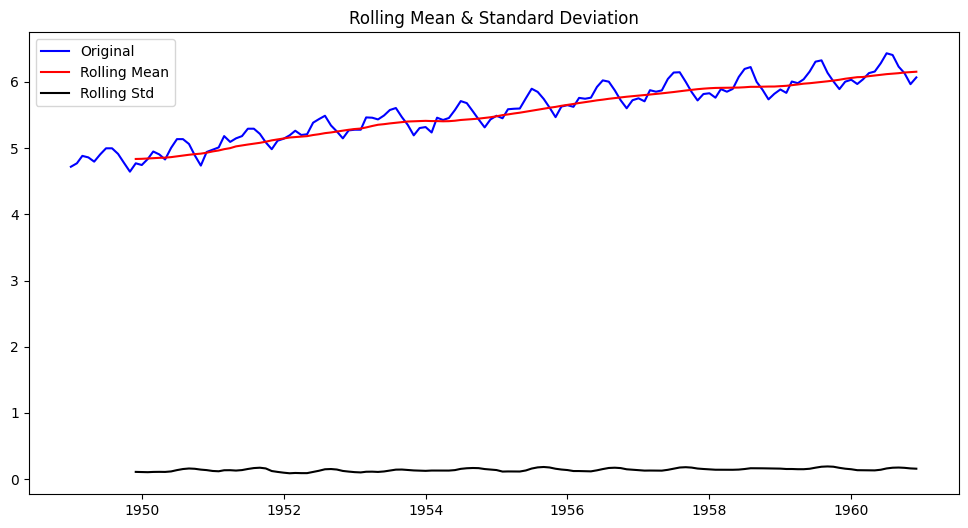

In [ ]:
#Melakukan transformasi log
data_log = np.log(data_passenger)

#Menghitung rolling statistics
rolmean = data_log.rolling(window=12).mean()
rolstd = data_log.rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(data_log, color='blue',label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

Sudah cukup mendekati stasioner, terlihat secara standard deviasi sudah stasioner tapi secara rata-rata belum begitu stasioner. Coba kita differencing sekali tapi dari data log ini.

### Coba differencing data log

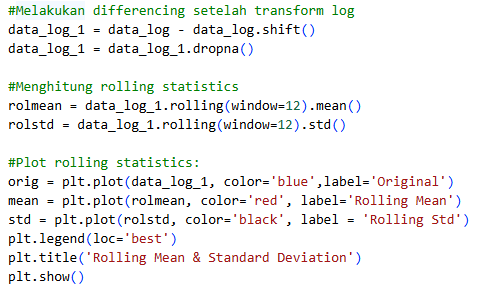

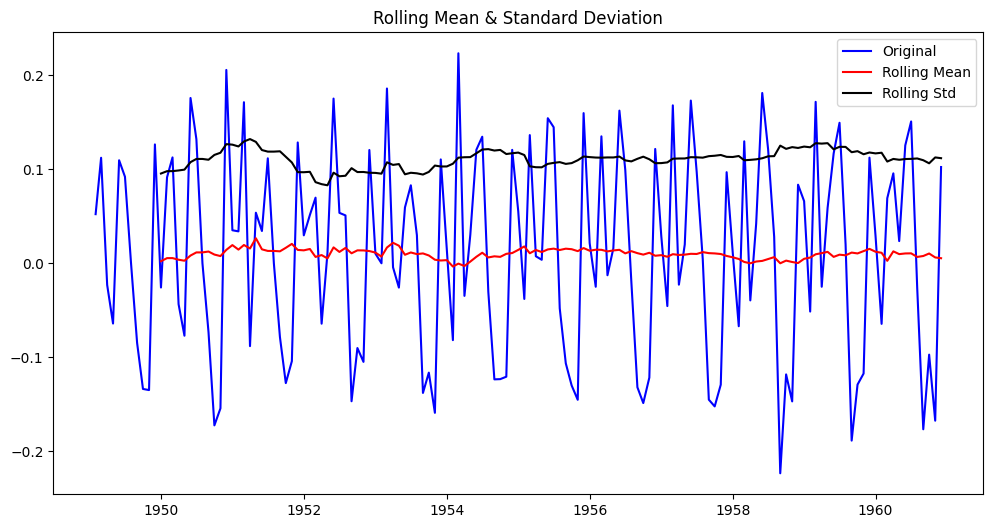

In [ ]:
#Melakukan differencing setelah transform log
data_log_1 = data_log - data_log.shift()
data_log_1 = data_log_1.dropna()

#Menghitung rolling statistics
rolmean = data_log_1.rolling(window=12).mean()
rolstd = data_log_1.rolling(window=12).std()

#Plot rolling statistics:
orig = plt.plot(data_log_1, color='blue',label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
std = plt.plot(rolstd, color='black', label = 'Rolling Std')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show()

Karena secara visual sudah stasioner secara rata-rata dan standard deviasi, kita coba uji diagnostiknya

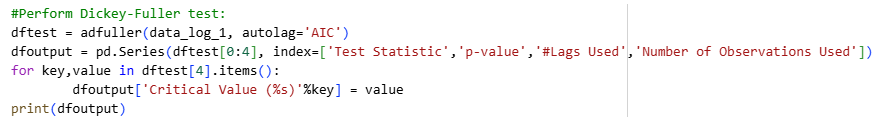

In [ ]:
#Perform Dickey-Fuller test:
dftest = adfuller(data_log_1, autolag='AIC')
dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
for key,value in dftest[4].items():
    dfoutput['Critical Value (%s)'%key] = value
print(dfoutput)

NameError: name 'adfuller' is not defined

karena p-value = 0.07, jika menggunakan CI 95% data ini Ho gagal ditolak. Tetapi jika menggunakan CI 90%, Ho ditolak, artinya data sudah stasioner  

## Training Model

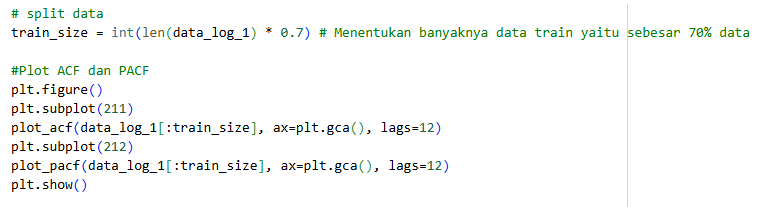

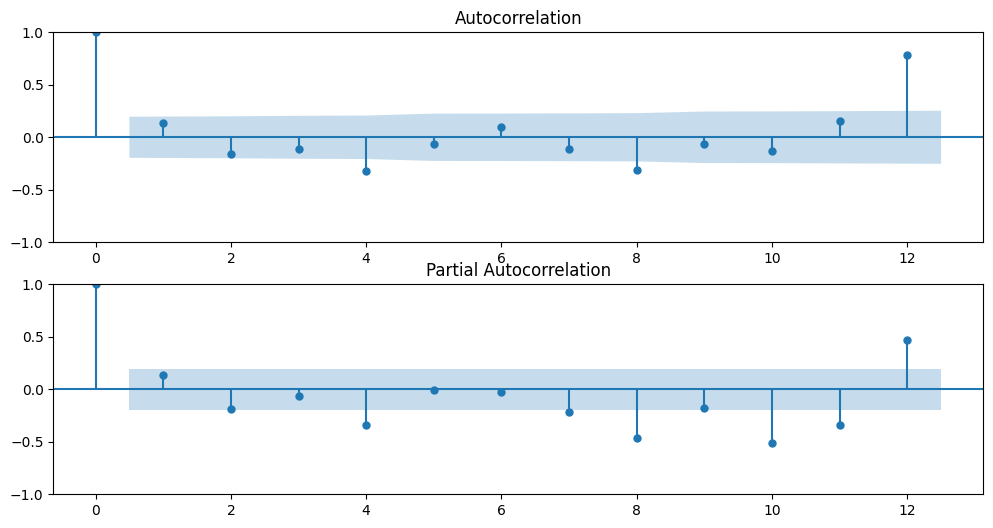

In [ ]:
# split data
train_size = int(len(data_log_1) * 0.7) # Menentukan banyaknya data train yaitu sebesar 70% data

#Plot ACF dan PACF
plt.figure()
plt.subplot(211)
plot_acf(data_log_1[:train_size], ax=plt.gca(), lags=12)
plt.subplot(212)
plot_pacf(data_log_1[:train_size], ax=plt.gca(), lags=12)
plt.show()


Terlihat bahwa keduanya cut off lag ke-1, lalu 4, lalu 8, ini menunjukkan pola seasonal (musiman) dengan orde 4. Sehingga kemungkinan modelnya


1. ARIMA(1, 1, 1) (p=1, d=1 karena sudah differencing sekali, q=1)
2. SARIMA(1, 1, 1)4, karena mencapai max/min tiap 4

Karena kita belum belajar SARIMA, jadi kita menggunakan ARIMA(1, 1, 1) saja

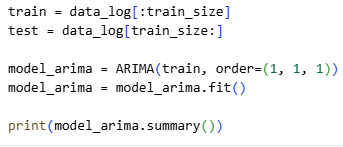

In [ ]:
train = data_log[:train_size]                #menggunakan data sebelum differencing, karena komponen differencingnya sudah diwakili model
test = data_log[train_size:]

model_arima = ARIMA(train, order=(1, 1, 1))
model_arima = model_arima.fit()

print(model_arima.summary())

                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                  88.270
Date:                Sat, 30 May 2026   AIC                           -170.541
Time:                        11:42:23   BIC                           -162.756
Sample:                    01-01-1949   HQIC                          -167.391
                         - 04-01-1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6035      0.215     -2.806      0.005      -1.025      -0.182
ma.L1          0.8382      0.128      6.533      0.000       0.587       1.090
sigma2         0.0098      0.002      5.144      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


1. Terlihat bahwa koefisien AR dan MA sudah signifikan (p-value < 0.10). Selain itu, sigma2 = 0.0098 menandakan variansi error/white noise yang cukup rendah

2. Uji autokorelasi

Nilai prob dari Ljung-Box = 0.83 > 0.10, artinya residualnya tidak mengalami autokorelasi

3. Uji Heteroskedastisitas

Nilai prob heteroskedastisitasnya 0.74 > 0.10, artinya varians dari white noise/residualnya konstan

4. Uji Normalitas

Karena p-valuenya >=0.10, maka residualnya sudah berdistribusi normal.
Pada prakteknya **uji statistik untuk residual (point 2-4) ini jarang digunakan sebagai kriteria model yang bagus, tapi bisa untuk memperkuat model sudah cukup baik.**

**Yang lebih utama untuk menentukan model yang bagus adalah dari visualisasi hasil prediksinya, MSE, RMSE, MAE, MAPE, lalu bisa juga dari AIC/BIC terendah.**

## Plotting Prediksi

mse =  12119.451501688623
rmse =  110.08838041177926
mae =  84.04874880060136
mape =  0.17818039731272964


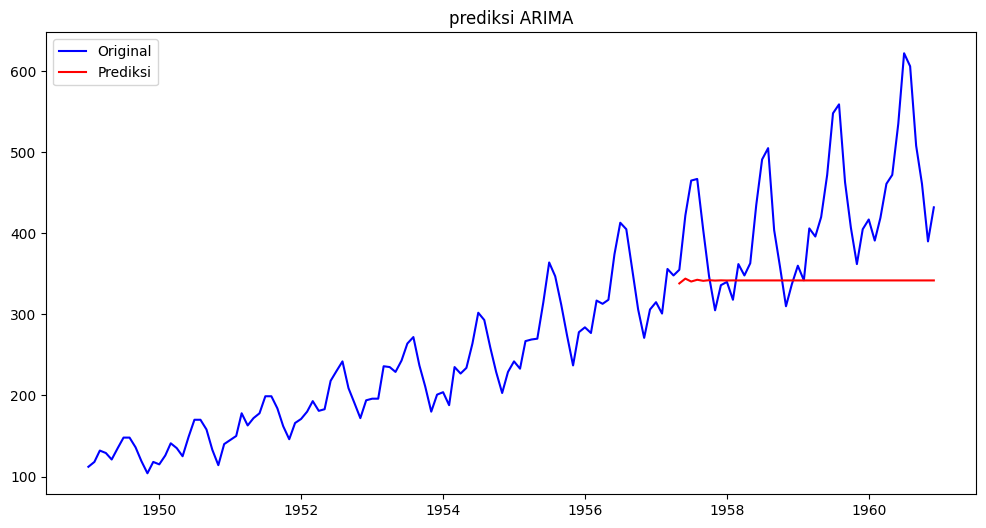

In [ ]:
pred = model_arima.predict(start=len(train), end=len(data_log) - 1)  #hitung prediksi dari indeks testingnya saja
pred.index = test.index  #menyamakan indeks

test_exp = np.exp(test)
pred_exp = np.exp(pred)  #karena ditraining dengan transformasi log, kita kembalikan dulu ke data aslinya. Tidak perlu dilakukan jika tidak ada transformasi

print('mse = ', mean_squared_error(test_exp, pred_exp))
print('rmse = ', root_mean_squared_error(test_exp, pred_exp))
print('mae = ', mean_absolute_error(test_exp, pred_exp))
print('mape = ', mean_absolute_percentage_error(test_exp, pred_exp))

orig = plt.plot(data_passenger, color='blue',label='Original')
prediksi = plt.plot(pred_exp, color='red',label='Prediksi')
plt.legend(loc='best')
plt.title('prediksi ARIMA')
plt.show()

Berdasarkan hasil prediksi terlihat kurang bagus, kemungkinan karena memang ada efek musiman sehingga seharusnya menggunakan model SARIMA

# Modifikasi Model ARIMA dan fungsi Auto arima

## Modifikasi intercept
Jika data terlihat berfluktuasi namun dalam jangka panjang menunjukkan trend naik/turun, maka bisa saja modelnya gabungan ARIMA dan trend. Misalnya:

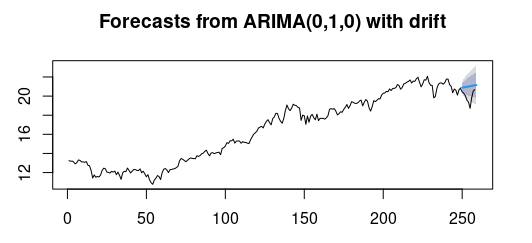

Pada kodingan python, tambahannya ada di bagian :    

model_arima = ARIMA(train, order=(1, 1, 1), **trend='t'**)

secara default, trend='n' (hanya stasioner). Namun, kita bisa modifikasi modelnya. Misalnya pada model AR(1) :

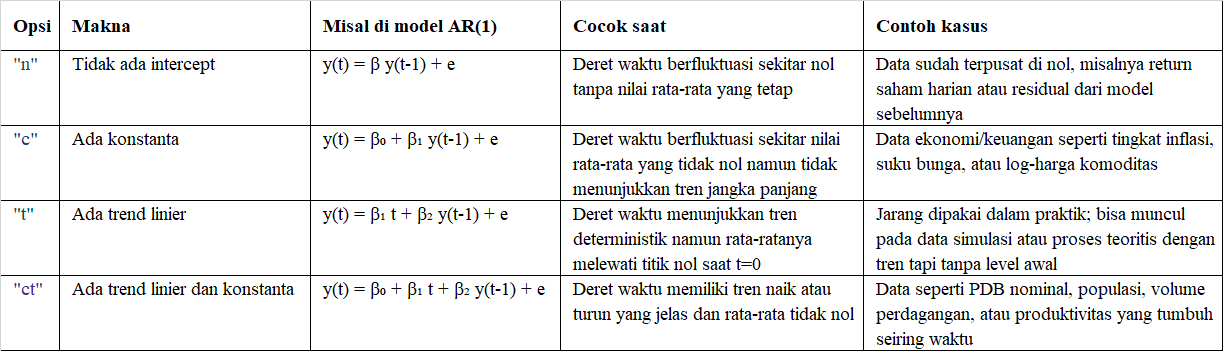

## Auto arima
Mirip dengan regresi linier yang memiliki stepwise, di ARIMA ada autoarima yang membantu mencari kombinasi p,d, q, dan penggabungan trend terbaik. Auto arima akan memberikan saran berdasarkan nilai AIC dan BIC-nya.

In [ ]:
# Use auto_arima to find the best ARIMA model
model = auto_arima(data_passenger,
                      start_p=0, start_q=0,
                      test='adf',       # test adf untuk mencari yg stasioner
                      max_p=10, max_q=10, # Maximum p and q
                      seasonal=False,    # Seasonal ARIMA, abaikan dulu
                      stepwise=True)    # Stepwise search to find the best model
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(2, 0, 1)   Log Likelihood                -699.125
Date:                Tue, 19 May 2026   AIC                           1408.249
Time:                        19:35:48   BIC                           1423.098
Sample:                    01-01-1949   HQIC                          1414.283
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     19.6007     12.051      1.627      0.104      -4.018      43.219
ar.L1          0.4990      0.131      3.822      0.000       0.243       0.755
ar.L2          0.4314      0.124      3.466      0.0

# Tugas Kelompok



1. Buat 3 model ARIMA yang berbeda dari data ini, lengkap dengan uji stasioner hingga evaluasi model.
2. Kombinasi yang bisa dilakukan : menggunakan transformasi yang berbeda/ tidak pakai transformasi, mengubah p/d/q, jika perlu cek outlier dan lakukan interpolasi, kombinasikan dengan ada intercept atau tidak.
3. Bandingkan MSE, RMSE, MAE, MAPE, AIC, BIC, varians error, dan hasil visualisasi prediksi dari model latihan dengan 3 model kalian dan tentukan mana yang terbaik
4. Tulis report hasil percobaan dan perbandingan forecastnya di format pdf dan cantumkan pula link google colabnya di report
5. Silahkan perwakilan kelompok mengirim via email : utih.amartiwi@staff.uinjkt.ac.id, cantumkan nama dan NIM anggota kelompok
Deadline : Kamis, 4 Juni 2026 pukul 23.59 WIB